In [17]:
#import packages needed for EDA
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df= pd.read_csv(r"C:\Users\nnzen\Downloads\bank.csv")
df.head(10)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes
5,42,management,single,tertiary,no,0,yes,yes,unknown,5,may,562,2,-1,0,unknown,yes
6,56,management,married,tertiary,no,830,yes,yes,unknown,6,may,1201,1,-1,0,unknown,yes
7,60,retired,divorced,secondary,no,545,yes,no,unknown,6,may,1030,1,-1,0,unknown,yes
8,37,technician,married,secondary,no,1,yes,no,unknown,6,may,608,1,-1,0,unknown,yes
9,28,services,single,secondary,no,5090,yes,no,unknown,6,may,1297,3,-1,0,unknown,yes


In [18]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


In [19]:
df[df['pdays'] < 0].head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [20]:
df.dtypes
df.describe(include = 'O')

,job,marital,education,default,housing,loan,contact,month,poutcome,deposit
count,11162,11162,11162,11162,11162,11162,11162,11162,11162,11162
unique,12,3,4,2,2,2,3,12,4,2
top,management,married,secondary,no,no,no,cellular,may,unknown,no
freq,2566,6351,5476,10994,5881,9702,8042,2824,8326,5873


In [21]:
df['deposit'].value_counts()

deposit
no     5873
yes    5289
Name: count, dtype: int64

In [22]:
# Investigating distribution of points from the "deposit" column wrt to "duration"
#Longer duration increases likelihood of 'yes' in 'deposit'
#Would have to exclude 'duration' from the model

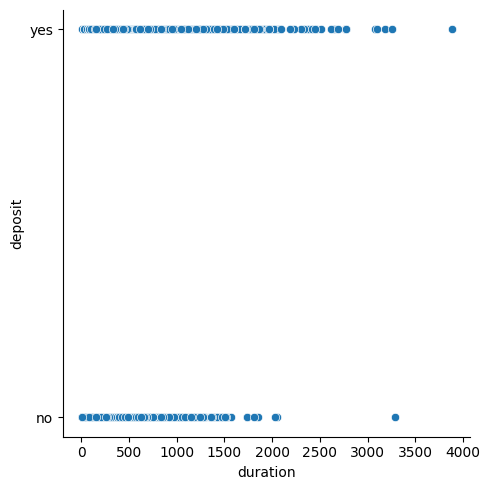

In [23]:
sns.relplot(x = 'duration', y = 'deposit', data = df)

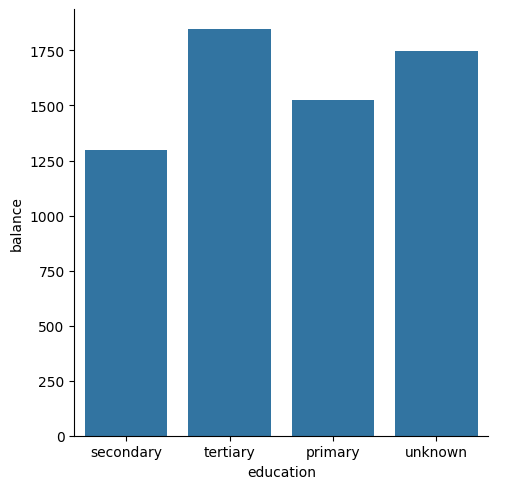

In [24]:
sns.catplot(x = 'education', y = 'balance', data = df, kind = 'bar', errorbar = None)

In [25]:
df['education'].value_counts()

education
secondary    5476
tertiary     3689
primary      1500
unknown       497
Name: count, dtype: int64

In [26]:
df.groupby('education')['balance'].median()

education
primary      472.0
secondary    494.0
tertiary     658.0
unknown      694.0
Name: balance, dtype: float64

In [27]:
df['contact'].value_counts()

contact
cellular     8042
unknown      2346
telephone     774
Name: count, dtype: int64

In [28]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [29]:
deposit_df = df.copy()

In [30]:
#Filtering out unknowns and nulls from 'education', 'job', and 'contact' columns

In [31]:
deposit_df = deposit_df[deposit_df['education'] != 'unknown']

In [32]:
deposit_df['education'].value_counts()

education
secondary    5476
tertiary     3689
primary      1500
Name: count, dtype: int64

In [33]:
deposit_df['job'].value_counts()

job
management       2482
blue-collar      1858
technician       1771
admin.           1294
services          882
retired           731
self-employed     394
unemployed        350
entrepreneur      314
student           293
housemaid         265
unknown            31
Name: count, dtype: int64

In [34]:
deposit_df = deposit_df[deposit_df['job'] != 'unknown']

In [35]:
deposit_df['job'].value_counts()

job
management       2482
blue-collar      1858
technician       1771
admin.           1294
services          882
retired           731
self-employed     394
unemployed        350
entrepreneur      314
student           293
housemaid         265
Name: count, dtype: int64

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
 [Text(0, 0, 'admin.'),
  Text(1, 0, 'technician'),
  Text(2, 0, 'services'),
  Text(3, 0, 'management'),
  Text(4, 0, 'retired'),
  Text(5, 0, 'blue-collar'),
  Text(6, 0, 'unemployed'),
  Text(7, 0, 'entrepreneur'),
  Text(8, 0, 'housemaid'),
  Text(9, 0, 'self-employed'),
  Text(10, 0, 'student')])

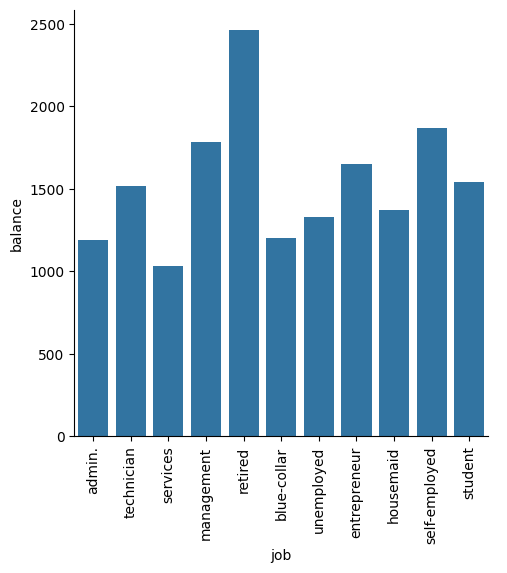

In [36]:
sns.catplot(x='job', y ='balance', data=deposit_df , errorbar= None, kind = 'bar')
plt.xticks(rotation = 90)

In [37]:
deposit_df['housing'].value_counts()

housing
no     5530
yes    5104
Name: count, dtype: int64

In [38]:
deposit_df['default'].value_counts()

default
no     10475
yes      159
Name: count, dtype: int64

In [39]:
deposit_df['contact']=deposit_df['contact'].replace('unknown','cellular')
deposit_df['contact'].value_counts()

contact
cellular     9933
telephone     701
Name: count, dtype: int64

In [40]:
deposit_df['month'].value_counts()

month
may    2706
aug    1457
jul    1430
jun    1167
nov     910
apr     874
feb     740
oct     362
jan     320
sep     297
mar     268
dec     103
Name: count, dtype: int64

In [41]:
deposit_df['poutcome'].value_counts()

poutcome
unknown    7941
failure    1176
success    1005
other       512
Name: count, dtype: int64

In [42]:
#Most of 'poutcome' column is unknown
#Will have to exclude from the model

In [43]:
deposit_df.drop('poutcome', axis=1, inplace = True)
deposit_df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,deposit
0,59,admin.,married,secondary,no,2343,yes,no,cellular,5,may,1042,1,-1,0,yes
1,56,admin.,married,secondary,no,45,no,no,cellular,5,may,1467,1,-1,0,yes
2,41,technician,married,secondary,no,1270,yes,no,cellular,5,may,1389,1,-1,0,yes
3,55,services,married,secondary,no,2476,yes,no,cellular,5,may,579,1,-1,0,yes
4,54,admin.,married,tertiary,no,184,no,no,cellular,5,may,673,2,-1,0,yes


In [44]:
deposit_df = pd.get_dummies(deposit_df, columns = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact','month'], drop_first = True, dtype='int')

In [45]:
deposit_df.head()

,age,balance,day,duration,campaign,pdays,previous,deposit,job_blue-collar,job_entrepreneur,...,month_dec,month_feb,month_jan,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep
0,59,2343,5,1042,1,-1,0,yes,0,0,...,0,0,0,0,0,0,1,0,0,0
1,56,45,5,1467,1,-1,0,yes,0,0,...,0,0,0,0,0,0,1,0,0,0
2,41,1270,5,1389,1,-1,0,yes,0,0,...,0,0,0,0,0,0,1,0,0,0
3,55,2476,5,579,1,-1,0,yes,0,0,...,0,0,0,0,0,0,1,0,0,0
4,54,184,5,673,2,-1,0,yes,0,0,...,0,0,0,0,0,0,1,0,0,0


In [46]:
X= deposit_df.drop('deposit', axis = 1)
y= deposit_df['deposit'].map({'yes':1,'no':0})
y.value_counts()

deposit
0    5613
1    5021
Name: count, dtype: int64

In [47]:
X.head()

,age,balance,day,duration,campaign,pdays,previous,job_blue-collar,job_entrepreneur,job_housemaid,...,month_dec,month_feb,month_jan,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep
0,59,2343,5,1042,1,-1,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
1,56,45,5,1467,1,-1,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
2,41,1270,5,1389,1,-1,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
3,55,2476,5,579,1,-1,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
4,54,184,5,673,2,-1,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0


In [48]:
X.describe()

,age,balance,day,duration,campaign,pdays,previous,job_blue-collar,job_entrepreneur,job_housemaid,...,month_dec,month_feb,month_jan,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep
count,10634.000000,10634.000000,10634.000000,10634.000000,10634.000000,10634.000000,10634.000000,10634.000000,10634.000000,10634.000000,...,10634.000000,10634.000000,10634.000000,10634.000000,10634.000000,10634.000000,10634.000000,10634.000000,10634.000000,10634.000000
mean,41.027083,1517.947339,15.638330,373.298006,2.501411,51.325842,0.837784,0.174723,0.029528,0.024920,...,0.009686,0.069588,0.030092,0.134474,0.109742,0.025202,0.254467,0.085575,0.034042,0.027929
std,11.739332,3224.425115,8.404122,349.198795,2.632235,108.922919,2.317528,0.379748,0.169289,0.155889,...,0.097944,0.254464,0.170849,0.341177,0.312583,0.156746,0.435582,0.279748,0.181345,0.164778
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,32.000000,119.000000,8.000000,138.000000,1.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,38.000000,542.000000,15.000000,255.000000,2.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,49.000000,1693.000000,21.000000,500.000000,3.000000,13.750000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
max,95.000000,81204.000000,31.000000,3881.000000,43.000000,854.000000,58.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [49]:
#Importing all necessary models for modelling the data and evaluting the model

In [50]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV, cross_val_score, KFold, train_test_split
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import mean_squared_error, roc_auc_score, roc_curve, confusion_matrix, precision_score, recall_score, f1_score

In [51]:
X_train,X_test,y_train,y_test = train_test_split(X, y, random_state = 42, test_size = 0.2)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
y_train = y_train.values
y_test = y_test.values

In [ ]:
# Evaluating the best model to fit the data with based on cross-validation score
# Focusing more on models that work better with a binary target variable

In [101]:
models = {'Logistic Regression': LogisticRegression(), 'Ridge Classifier' : RidgeClassifier(), \
          'Decision Tree Classifier' : DecisionTreeClassifier(), 'Hist Gradient Boosting Classifier':HistGradientBoostingClassifier(), \
          'KNN': KNeighborsClassifier()}
results = []

In [53]:
for name, model in models.items():
    kf= KFold(n_splits = 6, random_state = 42, shuffle = True)
    cv_results = cross_val_score(model, X_train_scaled, y_train, cv = kf)
    print(f'{name} train set cross val score: {cv_results.mean()}')


Logistic Regression train set cross val score: 0.8031019997285961
Ridge Classifier train set cross val score: 0.793462850689077
Decision Tree Classifier train set cross val score: 0.7723042184714523
Hist Gradient Boosting Classifier train set cross val score: 0.8507108092711281
KNN train set cross val score: 0.7484429947454494


In [ ]:
#As expected, the Logistic Regression has a high score, but Gradient Boosting Classifier is better
#Gradient Boosting Classifier seems to take longer to run than every other model.
#Will move forward with Gradient Boosting Classifier regardless

In [ ]:
#Finding the optimal hyperparameters for Gradiant Boosting Classifier based on RandomizedSearchCV

In [54]:
import numpy as np
kf = KFold(n_splits = 5, shuffle = True, random_state =12)
param_grid = {'learning_rate' : np.linspace(0.0001,1,20),
              'max_leaf_nodes': np.arange(2,202,20),
                'max_iter': np.arange(10,200,10),
              'l2_regularization': np.linspace(0.001,1,10),
             'class_weight':['balanced', None,{0:0.8,1:0.2}]}
hgbc = HistGradientBoostingClassifier()
hgbc_CV = RandomizedSearchCV(hgbc, param_grid, cv = kf, n_iter = 4)
hgbc_CV.fit(X_train_scaled, y_train)
print(hgbc_CV.best_params_, hgbc_CV.best_score_)

{'max_leaf_nodes': 162, 'max_iter': 50, 'learning_rate': 0.6316157894736842, 'l2_regularization': 0.889, 'class_weight': 'balanced'} 0.8437765577862196


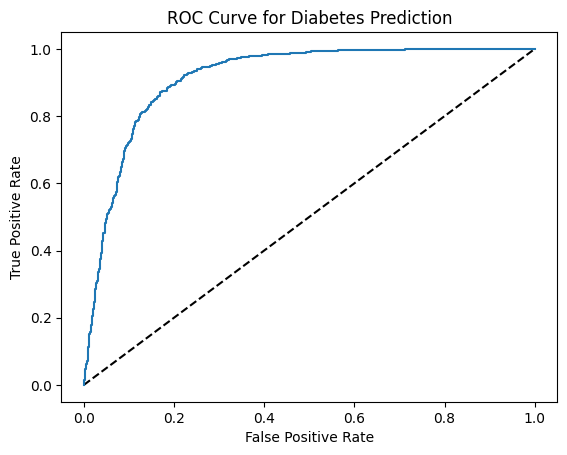

0.8487727523441808
[[930 217]
 [111 869]]


In [55]:
hgbc_opt = HistGradientBoostingClassifier(max_leaf_nodes= 22, max_iter= 70, learning_rate=0.112, l2_regularization=0.223, class_weight= 'balanced')
hgbc_opt.fit(X_train_scaled, y_train)
y_pred = hgbc_opt.predict(X_test_scaled)
y_prob = hgbc_opt.predict_proba(X_test_scaled)[:,1]
conf_mat = confusion_matrix(y_test, y_pred)
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot([0, 1],[0, 1], 'k--')

plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Diabetes Prediction')
plt.show()
roc_auc = roc_auc_score(y_test, y_pred)
print(roc_auc)
print(conf_mat)

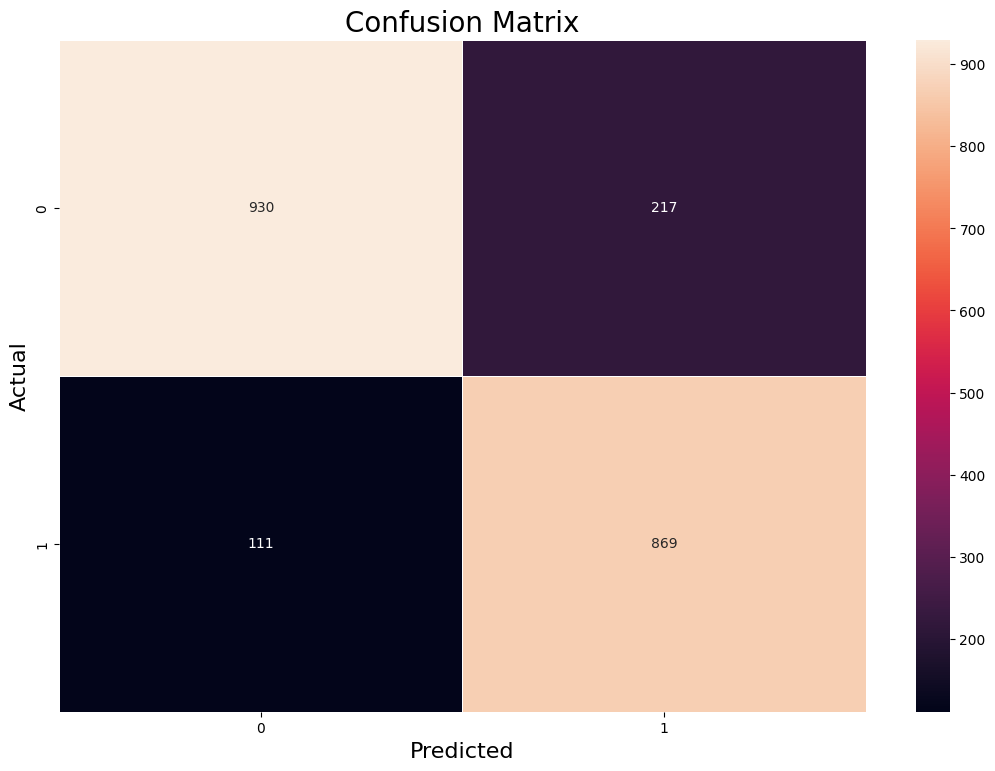

In [56]:
f, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(conf_mat, annot=True, fmt="d", linewidths=.5, ax=ax)
plt.title("Confusion Matrix", fontsize=20)
plt.subplots_adjust(left=0.15, right=0.99, bottom=0.15, top=0.99)
ax.set_yticks(np.arange(conf_mat.shape[0]) + 0.5, minor=False)
ax.set_xlabel('Predicted', fontsize=16)
ax.set_ylabel('Actual', fontsize=16)
plt.show()

In [57]:
print(f'Prediction Score: {precision_score(y_test, y_pred)}\nRecall Score: {recall_score(y_test, y_pred)}\nF1 Score: {f1_score(y_test, y_pred)}')

Prediction Score: 0.8001841620626151
Recall Score: 0.886734693877551
F1 Score: 0.8412391093901258
